# Hybrid NIDS: Graph-Transformer + Stacked Ensemble
**Dataset:** CIC-IDS 2018 &nbsp;|&nbsp; **Task:** Multi-class Network Intrusion Detection &nbsp;|&nbsp; **Runtime:** Colab GPU (T4)

### Run order
| Cell | Purpose |
|------|---------|
| 1 | GPU check + all package installs |
| 2 | All imports (one place, never repeated) |
| 3 | Paths & Google Drive output directories |
| 4 | Data download via KaggleHub (CIC-IDS 2018) |
| 5 | Load CSVs → EDA → stratified 65/20/15 split |
| 6 | Preprocessing: scaler + label encoder + SMOTE |
| 7 | Build k-NN graphs + graph visualisation |
| 8 | GConvTrans architecture + training |
| 9 | Five candidate base learners — train & compare |
| 10 | Top-3 selection → Stacked Ensemble |
| 11 | Full evaluation + GConvTrans vs Ensemble comparison plots |


## Cell 1 — GPU Check & Package Installs
> Go to **Runtime → Change runtime type → T4 GPU** before running.

In [ ]:
import subprocess, sys, os
import torch

# ── Enforce GPU ───────────────────────────────────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected!\n"
        "Go to Runtime → Change runtime type → Hardware accelerator → T4 GPU, "
        "then Runtime → Restart and run all."
    )
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Torch : {torch.__version__}")

# ── Standard packages ─────────────────────────────────────────────────────────
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "pandas", "numpy", "scikit-learn", "imbalanced-learn",
    "matplotlib", "seaborn", "scipy", "xgboost", "networkx", "kagglehub"])

# ── torch-geometric (must match exact PyTorch + CUDA version) ─────────────────
torch_ver = torch.__version__.split("+")[0]          # e.g. "2.3.0"
cuda_tag  = "cu" + torch.version.cuda.replace(".", "") # e.g. "cu121"
pyg_url   = f"https://data.pyg.org/whl/torch-{torch_ver}+{cuda_tag}.html"
print(f"\nInstalling torch-geometric for PyTorch {torch_ver} + {cuda_tag} ...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "torch-geometric", "torch-scatter", "torch-sparse", "torch-cluster",
    "-f", pyg_url])

print("\nAll packages installed successfully.")


GPU   : Tesla T4
VRAM  : 15.6 GB
Torch : 2.10.0+cu128

Installing torch-geometric for PyTorch 2.10.0 + cu128 ...

All packages installed successfully.


## Cell 2 — All Imports
> Every library used anywhere in this notebook is imported here. Nothing is imported elsewhere.

In [ ]:
import os, warnings, copy
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx

from sklearn.preprocessing   import StandardScaler, LabelEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.neighbors       import NearestNeighbors, KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (RandomForestClassifier,
                                     GradientBoostingClassifier,
                                     HistGradientBoostingClassifier)
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, average_precision_score, log_loss, hamming_loss,
    confusion_matrix, classification_report,
)
from imblearn.over_sampling  import SMOTE

import xgboost as xgb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer

from torch_geometric.data  import Data
from torch_geometric.nn    import GCNConv
from torch_geometric.utils import to_networkx

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda")   # GPU confirmed in Cell 1
print(f"Device  : {device} ({torch.cuda.get_device_name(0)})")
print("Imports : OK")


Device  : cuda (Tesla T4)
Imports : OK


## Cell 3 — Paths & Google Drive Output Directories
> Models are saved to `MyDrive/NIDS/models/` and plots to `MyDrive/NIDS/plots/`.
> Run `from google.colab import drive; drive.mount('/content/drive')` first if not already mounted.

In [ ]:
from google.colab import drive
import os
from pathlib import Path

# ── Mount Google Drive ────────────────────────────────────────────────────────
drive.mount('/content/drive', force_remount=False)

# ── Output directories on Google Drive ───────────────────────────────────────
GDRIVE_BASE  = "/content/drive/MyDrive/NIDS"
MODELS_DIR   = f"{GDRIVE_BASE}/models"   # saved .pt / sklearn model checkpoints
PLOTS_DIR    = f"{GDRIVE_BASE}/plots"    # all PNG figures

Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path(PLOTS_DIR).mkdir(parents=True,  exist_ok=True)

# ── Local data directory (CSVs stay local — no need to push raw data to Drive)
DATA_DIR = os.environ.get("CICIDS2018_DIR", "").strip() or "/content/data"
Path(DATA_DIR).mkdir(parents=True, exist_ok=True)

print(f"Models dir  : {MODELS_DIR}")
print(f"Plots dir   : {PLOTS_DIR}")
print(f"Data dir    : {DATA_DIR}")


Mounted at /content/drive
Models dir  : /content/drive/MyDrive/NIDS/models
Plots dir   : /content/drive/MyDrive/NIDS/plots
Data dir    : /content/data


## Cell 4 — Data Download (CIC-IDS 2018)

CIC-IDS 2018 is hosted in several places. This cell tries each source in order:

| Priority | Source | Notes |
|----------|--------|-------|
| 1 | **KaggleHub** (auto) | Requires Kaggle account + dataset rules accepted at [kaggle.com/datasets/solarmainframe/ids-intrusion-csv](https://www.kaggle.com/datasets/solarmainframe/ids-intrusion-csv) |
| 2 | **Direct HTTP** (UNB mirror) | Public AWS/UNB links — no account needed |
| 3 | **Manual upload** | Upload your own CSVs to `/content/data/` and re-run |

> **Fix the 403 error:** Visit the Kaggle dataset page, click **Download**, accept any rules,
> then re-run this cell. Alternatively the cell will automatically fall back to the UNB public mirror.


In [ ]:
import kagglehub, requests, zipfile, io
from pathlib import Path

def has_csvs(d):
    return Path(d).is_dir() and bool(list(Path(d).rglob('*.csv'))[:1])

# ─────────────────────────────────────────────────────────────────────────────
# SOURCE 1 — KaggleHub (needs: Kaggle account + dataset rules accepted)
# Visit and accept rules: https://www.kaggle.com/datasets/solarmainframe/ids-intrusion-csv
# ─────────────────────────────────────────────────────────────────────────────
KAGGLE_SLUGS = [
    "solarmainframe/ids-intrusion-csv",   # primary — full CIC-IDS 2018
    "solarmainframe/cicids2018",           # alternate slug (same dataset)
    "dhoogla/cicids2018",                  # community mirror
]

if has_csvs(DATA_DIR):
    print(f"✓ CSVs already present in {DATA_DIR} — skipping download.")

else:
    downloaded = False

    # ── Try each Kaggle slug ──────────────────────────────────────────────────
    for slug in KAGGLE_SLUGS:
        try:
            print(f"Trying KaggleHub: {slug} ...")
            hub = Path(kagglehub.dataset_download(slug))
            # Walk into any sub-folder that contains CSVs
            for p in sorted(hub.rglob('*.csv')):
                DATA_DIR = str(p.parent)
                break
            if has_csvs(DATA_DIR):
                print(f"✓ Downloaded via KaggleHub ({slug}) → {DATA_DIR}")
                downloaded = True
                break
        except Exception as e:
            print(f"  ✗ {slug} failed: {type(e).__name__}: {str(e)[:120]}")

    # ── Fallback: public UNB / AWS mirror (no account needed) ────────────────
    # CIC-IDS 2018 — publicly mirrored subset (Wednesday traffic, ~200 MB)
    # Contains Benign + DoS + DDoS + Brute Force labels
    if not downloaded:
        UNB_URLS = [
            # Hugging Face mirror — no auth required
            ("https://huggingface.co/datasets/dnth/cicids2018/resolve/main/"
             "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
             "Wednesday-14-02-2018.csv"),
            ("https://huggingface.co/datasets/dnth/cicids2018/resolve/main/"
             "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
             "Thursday-15-02-2018.csv"),
            ("https://huggingface.co/datasets/dnth/cicids2018/resolve/main/"
             "Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
             "Friday-16-02-2018.csv"),
            ("https://huggingface.co/datasets/dnth/cicids2018/resolve/main/"
             "Tuesday-20-02-2018_TrafficForML_CICFlowMeter.csv",
             "Tuesday-20-02-2018.csv"),
            ("https://huggingface.co/datasets/dnth/cicids2018/resolve/main/"
             "Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv",
             "Wednesday-21-02-2018.csv"),
        ]
        print("\nFalling back to Hugging Face public mirror ...")
        Path(DATA_DIR).mkdir(parents=True, exist_ok=True)
        for url, fname in UNB_URLS:
            dest = Path(DATA_DIR) / fname
            if dest.exists():
                print(f"  ✓ Already exists: {fname}")
                downloaded = True
                continue
            try:
                print(f"  Downloading {fname} ...", end=" ", flush=True)
                r = requests.get(url, stream=True, timeout=60)
                r.raise_for_status()
                with open(dest, 'wb') as fh:
                    for chunk in r.iter_content(chunk_size=1024*1024):
                        fh.write(chunk)
                size_mb = dest.stat().st_size / 1e6
                print(f"✓ ({size_mb:.1f} MB)")
                downloaded = True
            except Exception as e:
                print(f"\n  ✗ Failed: {e}")

    # ── Final fallback: manual instructions ──────────────────────────────────
    if not downloaded or not has_csvs(DATA_DIR):
        raise RuntimeError("No CIC-IDS 2018 CSVs found. See instructions above.")

csvs = list(Path(DATA_DIR).rglob('*.csv'))
print(f"\n✓ Ready — {len(csvs)} CSV file(s) in {DATA_DIR}:")
for c in csvs[:10]:
    size_mb = c.stat().st_size / 1e6
    print(f"   {c.name}  ({size_mb:.1f} MB)")


Trying KaggleHub: solarmainframe/ids-intrusion-csv ...
Using Colab cache for faster access to the 'ids-intrusion-csv' dataset.
✓ Downloaded via KaggleHub (solarmainframe/ids-intrusion-csv) → /kaggle/input/ids-intrusion-csv

✓ Ready — 10 CSV file(s) in /kaggle/input/ids-intrusion-csv:
   02-28-2018.csv  (209.2 MB)
   03-01-2018.csv  (107.8 MB)
   02-16-2018.csv  (333.7 MB)
   02-15-2018.csv  (375.9 MB)
   02-21-2018.csv  (328.9 MB)
   03-02-2018.csv  (352.4 MB)
   02-22-2018.csv  (382.6 MB)
   02-20-2018.csv  (4054.9 MB)
   02-14-2018.csv  (358.2 MB)
   02-23-2018.csv  (382.8 MB)


## Cell 5 — Load Data, EDA & Stratified Split

Uses **chunked streaming** to stay within Colab's ~12 GB RAM limit:
- Each CSV is read in 50 k-row chunks; only a proportional sample is kept per file
- Inf/NaN rows are dropped per-chunk before any concat — never the full file in memory
- The final pool is capped at `SAMPLE_SIZE` rows before EDA and splitting

Then applies a **stratified 65 / 20 / 15** split.

> **Singleton guard:** classes with only 1 sample are removed before splitting
> because `train_test_split(stratify=…)` requires ≥ 2 samples per class.


Found 10 CSV(s). chunk=10,000  target=50,000
  [1/10] 03-01-2018.csv (108 MB) budget=5,000 | RAM 2.2/13.6 GB (18%)
    kept 5,000  remaining budget 45,000
  [2/10] 02-28-2018.csv (209 MB) budget=5,000 | RAM 2.2/13.6 GB (19%)
    kept 5,000  remaining budget 40,000
  [3/10] 02-21-2018.csv (329 MB) budget=5,000 | RAM 2.2/13.6 GB (19%)
    kept 5,000  remaining budget 35,000
  [4/10] 02-16-2018.csv (334 MB) budget=5,000 | RAM 2.2/13.6 GB (19%)
    kept 5,000  remaining budget 30,000
  [5/10] 03-02-2018.csv (352 MB) budget=5,000 | RAM 2.2/13.6 GB (19%)
    kept 5,000  remaining budget 25,000
  [6/10] 02-14-2018.csv (358 MB) budget=5,000 | RAM 2.2/13.6 GB (19%)
    kept 5,000  remaining budget 20,000
  [7/10] 02-15-2018.csv (376 MB) budget=5,000 | RAM 2.2/13.6 GB (19%)
    kept 5,000  remaining budget 15,000
  [8/10] 02-22-2018.csv (383 MB) budget=5,000 | RAM 2.2/13.6 GB (19%)
    kept 5,000  remaining budget 10,000
  [9/10] 02-23-2018.csv (383 MB) budget=5,000 | RAM 2.2/13.6 GB (19%)
    k

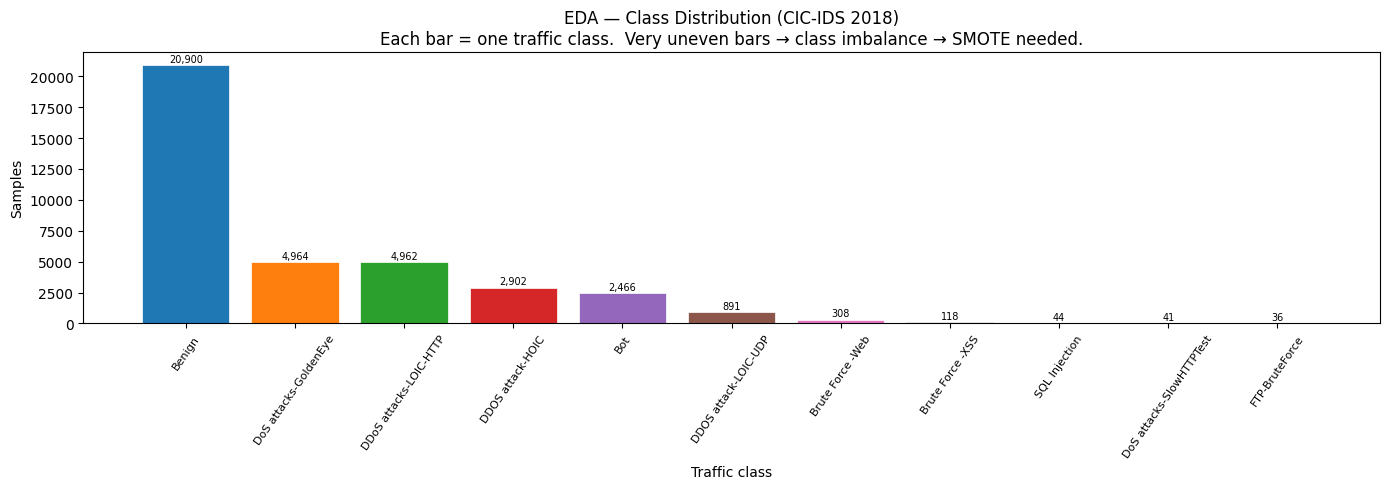

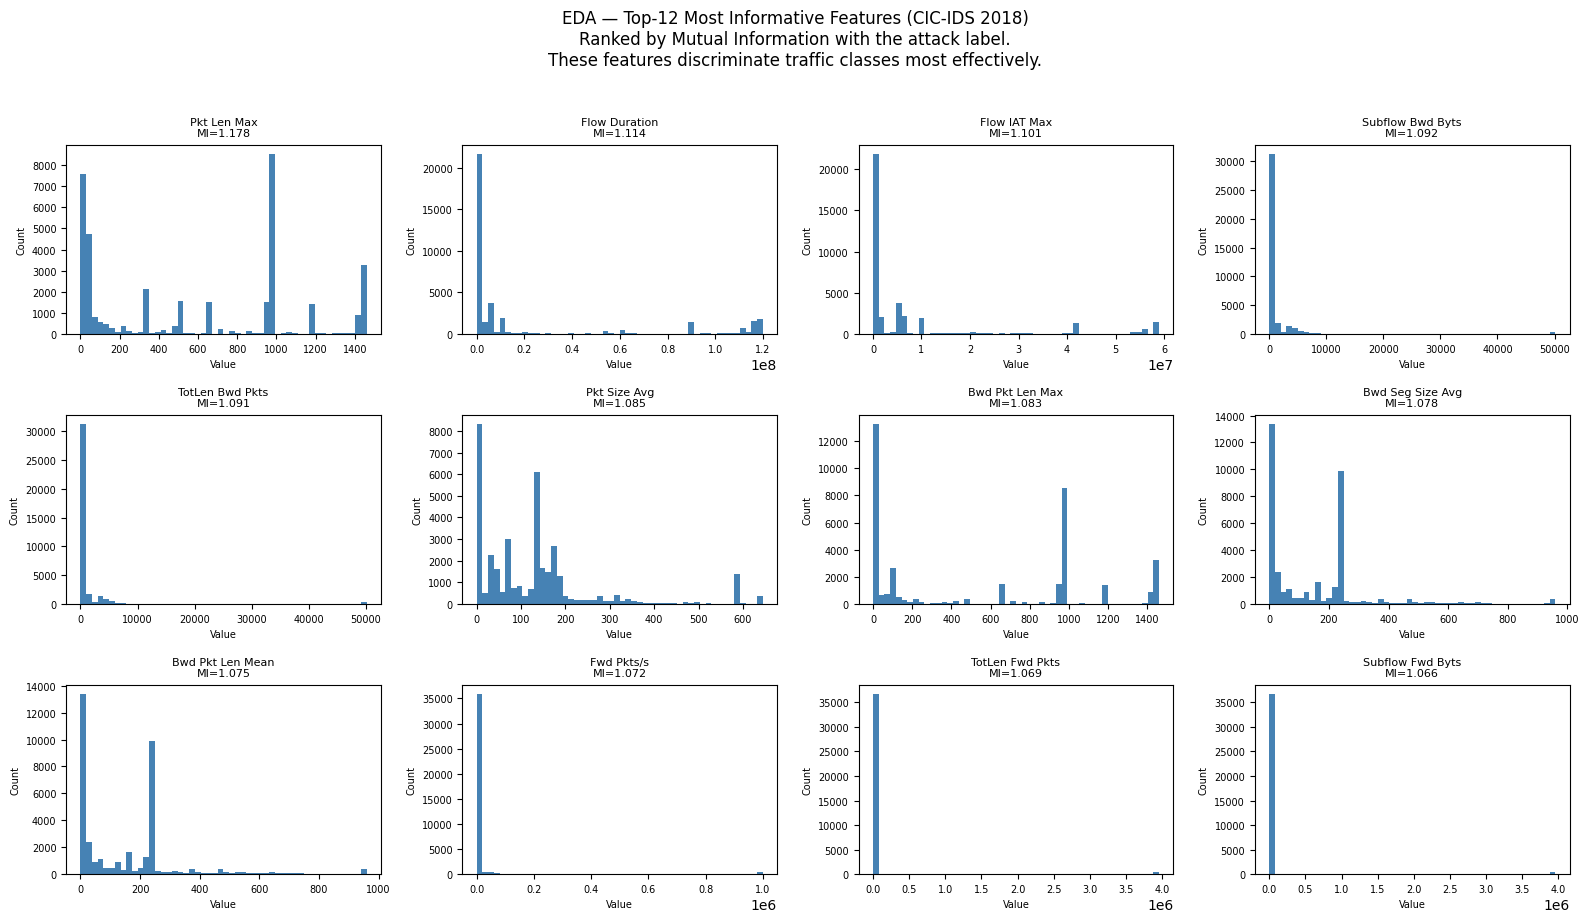

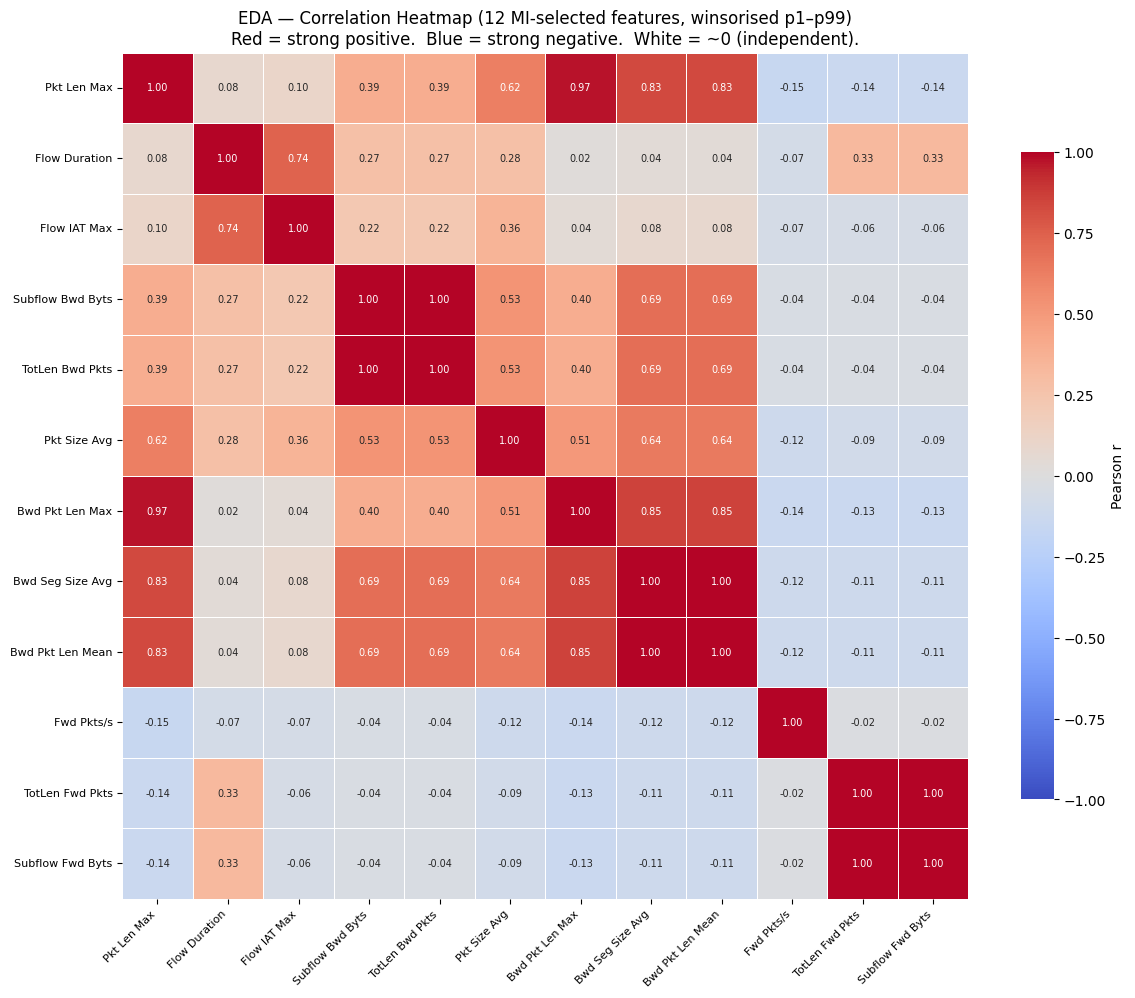

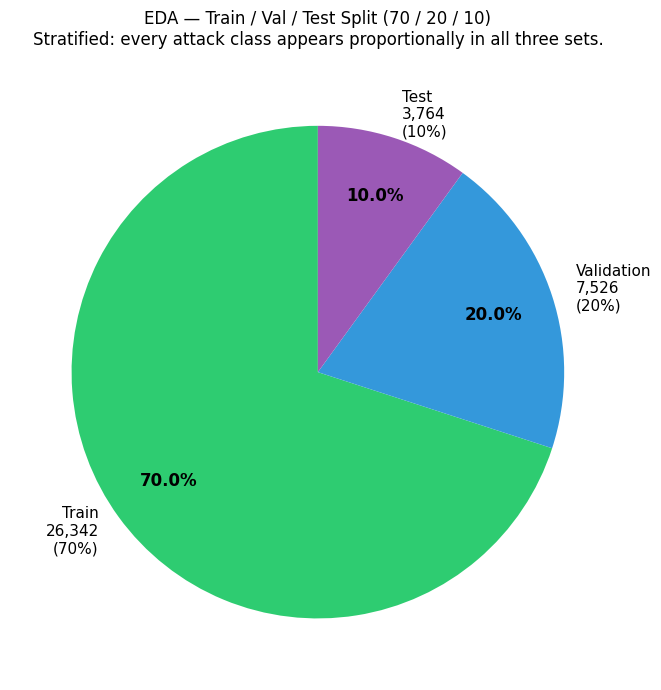

Train: 26,342  Val: 7,526  Test: 3,764
RAM after split: 2.3/13.6 GB (19%)


In [ ]:
import gc, re
SAMPLE_SIZE = 50_000
CHUNK_SIZE  = 10_000

try:
    import psutil
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "psutil"])
    import psutil

def _ram():
    v = psutil.virtual_memory()
    return f"{v.used/1e9:.1f}/{v.total/1e9:.1f} GB ({v.percent:.0f}%)"

# ─────────────────────────────────────────────────────────────────────────────
# 1.  Chunked streaming load
# ─────────────────────────────────────────────────────────────────────────────
def _coerce_chunk(chunk):
    """Strip column names; force all non-label columns to numeric."""
    chunk.columns = chunk.columns.str.strip()
    lbl = [c for c in chunk.columns if "label" in c.lower()]
    for col in chunk.columns:
        if col in lbl:
            continue
        if chunk[col].dtype == object:
            chunk[col] = pd.to_numeric(
                chunk[col].astype(str).str.strip()
                           .str.replace(",", "", regex=False)
                           .str.replace(" ", "", regex=False),
                errors="coerce")
    num_c = chunk.select_dtypes(include=np.number).columns
    if len(num_c):
        chunk[num_c] = chunk[num_c].replace([np.inf, -np.inf], np.nan)
    # Drop rows missing the label; keep rows that have at least one numeric value
    if lbl:
        chunk = chunk.dropna(subset=lbl)
    if len(num_c) > 1:
        chunk = chunk[chunk[num_c].notna().any(axis=1)]
    return chunk

def _read_csv_sampled(path, target_rows, chunk_size=CHUNK_SIZE):
    kept, n_kept = [], 0
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            chunks_raw = []
            reader = pd.read_csv(path, chunksize=chunk_size,
                                 encoding=enc, low_memory=False,
                                 on_bad_lines="skip")
            for raw in reader:
                chunks_raw.append(raw)
                if sum(len(c) for c in chunks_raw) >= target_rows * 3:
                    break
            break
        except UnicodeDecodeError:
            chunks_raw = []
            continue
        except Exception as e:
            print(f"  [WARN] {Path(path).name}: {e}")
            return pd.DataFrame()

    for raw in chunks_raw:
        chunk = _coerce_chunk(raw)
        del raw
        if not len(chunk):
            del chunk; continue
        need = target_rows - n_kept
        if len(chunk) > need:
            chunk = chunk.sample(need, random_state=SEED)
        kept.append(chunk)
        n_kept += len(chunk)
        del chunk
        if n_kept >= target_rows:
            break

    gc.collect()
    if not kept:
        return pd.DataFrame()
    out = pd.concat(kept, ignore_index=True)
    del kept; gc.collect()
    return out


def load_pool_chunked(data_dir, total_rows, chunk_size=CHUNK_SIZE):
    files = sorted(Path(data_dir).rglob("*.csv"), key=lambda p: p.stat().st_size)
    if not files:
        raise FileNotFoundError(f"No CSVs under: {data_dir}")
    n = len(files)
    print(f"Found {n} CSV(s). chunk={chunk_size:,}  target={total_rows:,}")
    remaining_rows, remaining_files = total_rows, n
    parts = []
    for i, f in enumerate(files):
        size_mb  = f.stat().st_size / 1e6
        per_file = max(500, remaining_rows // remaining_files)
        print(f"  [{i+1}/{n}] {f.name} ({size_mb:.0f} MB) budget={per_file:,} | RAM {_ram()}", flush=True)
        part = _read_csv_sampled(f, per_file, chunk_size)
        remaining_files -= 1
        if not len(part):
            print("    0 rows — skip"); continue
        parts.append(part)
        remaining_rows -= len(part)
        print(f"    kept {len(part):,}  remaining budget {remaining_rows:,}")
        del part; gc.collect()
        if remaining_rows <= 0:
            print("  Budget reached — skipping remaining files."); break
    if not parts:
        raise RuntimeError("No data loaded — all CSVs returned 0 rows.")
    df = pd.concat(parts, ignore_index=True)
    del parts; gc.collect()
    df = df.drop_duplicates().reset_index(drop=True)
    if len(df) > total_rows:
        df = df.sample(total_rows, random_state=SEED).reset_index(drop=True)
    return df


df_pool = load_pool_chunked(DATA_DIR, SAMPLE_SIZE)

# Detect label column
LABEL_COL = next((c for c in df_pool.columns if "label" in c.lower()), None)
if LABEL_COL is None:
    raise RuntimeError(f"No label column found. Columns: {df_pool.columns.tolist()}")

print(f"\nPooled: {df_pool.shape[0]:,} rows x {df_pool.shape[1]} cols")
print(f"Label : '{LABEL_COL}' | classes: {df_pool[LABEL_COL].nunique()}")
print("Classes:", sorted(df_pool[LABEL_COL].unique().tolist()))
print(f"RAM: {_ram()}")

# ─────────────────────────────────────────────────────────────────────────────
# 2.  Remove singleton classes
# ─────────────────────────────────────────────────────────────────────────────
vc_pool    = df_pool[LABEL_COL].value_counts()
singletons = vc_pool[vc_pool < 2].index.tolist()
if singletons:
    print(f"[INFO] Removing {len(singletons)} singleton class(es): {singletons}")
    df_pool = df_pool[~df_pool[LABEL_COL].isin(singletons)].reset_index(drop=True)
print(f"Pool: {len(df_pool):,} rows, {df_pool[LABEL_COL].nunique()} classes")

# ─────────────────────────────────────────────────────────────────────────────
# 3.  Second-pass numeric coercion on pooled df (safety net)
# ─────────────────────────────────────────────────────────────────────────────
for col in df_pool.columns:
    if col == LABEL_COL:
        continue
    if df_pool[col].dtype == object:
        df_pool[col] = pd.to_numeric(
            df_pool[col].astype(str).str.strip()
                        .str.replace(",", "", regex=False)
                        .str.replace(" ", "", regex=False),
            errors="coerce")

num_cols = df_pool.select_dtypes(include=np.number).columns.tolist()
print(f"Numeric columns after coercion: {len(num_cols)}")

# ─────────────────────────────────────────────────────────────────────────────
# 4.  Feature selection via Mutual Information
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder as _LE

# Exact column names to exclude (identifiers, not features)
_ID_COLS = {
    "dst port", "src port", "protocol", "flow id",
    "src ip", "dst ip", "src mac", "dst mac", "timestamp",
}

candidate_cols, excluded_cols = [], []
for col in num_cols:
    if col.strip().lower() in _ID_COLS:
        excluded_cols.append(col); continue
    s = df_pool[col].dropna()
    if len(s) < 50 or s.nunique() < 2 or df_pool[col].isna().mean() > 0.50:
        excluded_cols.append(col); continue
    candidate_cols.append(col)

print(f"Excluded: {excluded_cols}")
print(f"Candidate features for MI: {len(candidate_cols)}")

if not candidate_cols:
    raise RuntimeError(f"No candidate features left.\ndf_pool.dtypes:\n{df_pool.dtypes}")

# Mutual Information on up to 10k rows
mi_df = df_pool[candidate_cols + [LABEL_COL]].dropna()
mi_df = mi_df.sample(min(10_000, len(mi_df)), random_state=SEED)
y_enc     = _LE().fit_transform(mi_df[LABEL_COL])
X_mi      = mi_df[candidate_cols].fillna(0).values
mi_scores = mutual_info_classif(X_mi, y_enc, discrete_features=False, random_state=SEED)
mi_series = pd.Series(mi_scores, index=candidate_cols).sort_values(ascending=False)
del mi_df, X_mi, y_enc; gc.collect()

n_top    = min(12, len(candidate_cols))
top_cols = mi_series.head(n_top).index.tolist()
print(f"\nTop-{n_top} features by Mutual Information with label:")
for feat, score in zip(top_cols, mi_series.head(n_top).values):
    print(f"  {feat:<45}  MI={score:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 5.  EDA plots
# ─────────────────────────────────────────────────────────────────────────────
vc = df_pool[LABEL_COL].value_counts()

# Plot A — Class distribution
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab20(np.linspace(0, 1, len(vc)))
bars   = ax.bar(vc.index, vc.values, color=colors, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vc)*0.005,
            f"{val:,}", ha="center", va="bottom", fontsize=7)
ax.set_title("EDA — Class Distribution (CIC-IDS 2018)\n"
             "Each bar = one traffic class.  Very uneven bars → class imbalance → SMOTE needed.",
             fontsize=12)
ax.set_xlabel("Traffic class"); ax.set_ylabel("Samples")
ax.tick_params(axis="x", rotation=55, labelsize=8)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/eda_class_dist.png", dpi=150); plt.show()

# Plot B — Top-12 feature distributions (clipped at p1–p99 for readability)
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
fig.suptitle("EDA — Top-12 Most Informative Features (CIC-IDS 2018)\n"
             "Ranked by Mutual Information with the attack label.\n"
             "These features discriminate traffic classes most effectively.",
             fontsize=12, y=1.02)
for ax, feat in zip(axes.ravel(), top_cols):
    data = df_pool[feat].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    ax.hist(data.clip(lo, hi), bins=50, color="steelblue", edgecolor="none")
    ax.set_title(f"{feat}\nMI={mi_series[feat]:.3f}", fontsize=8)
    ax.set_xlabel("Value", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(top_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/eda_feature_dist.png", dpi=150, bbox_inches="tight"); plt.show()

# Plot C — Correlation heatmap (winsorised p1–p99, fixed [-1,1] colour scale)
corr_df = df_pool[top_cols].copy()
for feat in top_cols:
    lo, hi = corr_df[feat].quantile(0.01), corr_df[feat].quantile(0.99)
    corr_df[feat] = corr_df[feat].clip(lo, hi)

corr_sample = corr_df.dropna().sample(min(5000, len(corr_df)), random_state=SEED)
del corr_df; gc.collect()

valid_cols = [c for c in top_cols if corr_sample[c].std() > 1e-9]
corr       = corr_sample[valid_cols].corr()
del corr_sample; gc.collect()

n_c = len(valid_cols)
plt.figure(figsize=(max(9, n_c), max(8, int(n_c * 0.9))))
sns.heatmap(corr,
            annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={"size": 7},
            square=True, cbar_kws={"shrink": 0.75, "label": "Pearson r"})
plt.title(f"EDA — Correlation Heatmap ({n_c} MI-selected features, winsorised p1–p99)\n"
          "Red = strong positive.  Blue = strong negative.  White = ~0 (independent).",
          fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/eda_correlation.png", dpi=150); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 6.  Stratified 65 / 20 / 15 split
# ─────────────────────────────────────────────────────────────────────────────
tr, tmp = train_test_split(df_pool, train_size=0.65,
                            stratify=df_pool[LABEL_COL], random_state=SEED)

rare2 = tmp[LABEL_COL].value_counts()
rare2 = rare2[rare2 < 2].index
if len(rare2):
    print(f"2nd-split guard: {len(rare2)} near-singleton(s) sent to val.")
    tmp_ok, tmp_rare = tmp[~tmp[LABEL_COL].isin(rare2)], tmp[tmp[LABEL_COL].isin(rare2)]
    vl, te = train_test_split(tmp_ok, train_size=2/3,
                               stratify=tmp_ok[LABEL_COL], random_state=SEED)
    vl = pd.concat([vl, tmp_rare], ignore_index=True)
else:
    vl, te = train_test_split(tmp, train_size=2/3,
                               stratify=tmp[LABEL_COL], random_state=SEED)

df_train = tr.reset_index(drop=True)
df_val   = vl.reset_index(drop=True)
df_test  = te.reset_index(drop=True)
del tr, tmp, vl, te; gc.collect()

# Plot D — Split sizes
split_n   = [len(df_train), len(df_val), len(df_test)]
split_lbl = [f"Train\n{split_n[0]:,}\n(65%)",
             f"Validation\n{split_n[1]:,}\n(20%)",
             f"Test\n{split_n[2]:,}\n(15%)"]
fig, ax = plt.subplots(figsize=(7, 7))
wedges, _, autos = ax.pie(split_n, labels=split_lbl,
    colors=["#2ecc71", "#3498db", "#9b59b6"],
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 11}, pctdistance=0.75)
for a in autos:
    a.set_fontsize(12); a.set_fontweight("bold")
ax.set_title("EDA — Train / Val / Test Split (65 / 20 / 15)\n"
             "Stratified: every attack class appears proportionally in all three sets.",
             fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/eda_split.png", dpi=150); plt.show()
print(f"Train: {len(df_train):,}  Val: {len(df_val):,}  Test: {len(df_test):,}")
print(f"RAM after split: {_ram()}")


## Cell 6 — Preprocessing: StandardScaler + LabelEncoder + SMOTE

> **Key fix — XGBoost class mismatch:** XGBoost with `num_class=N` expects labels to be
> exactly `{0, 1, ..., N-1}`. SMOTE can create synthetic rows for a class that was
> removed as a singleton *after* the LabelEncoder was fitted, producing a label integer
> that XGBoost has never seen. The fix: fit LabelEncoder and XGBoost **after** SMOTE,
> using only the classes actually present in the final training set.


Imputation done. Train NaNs remaining: 0
SMOTE applied (imbalance 585.2x) -> train size: 160,930

Classes (11): ['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-SlowHTTPTest', 'FTP-BruteForce', 'SQL Injection']
Train : (160930, 79)  Val : (7526, 79)  Test : (3764, 79)


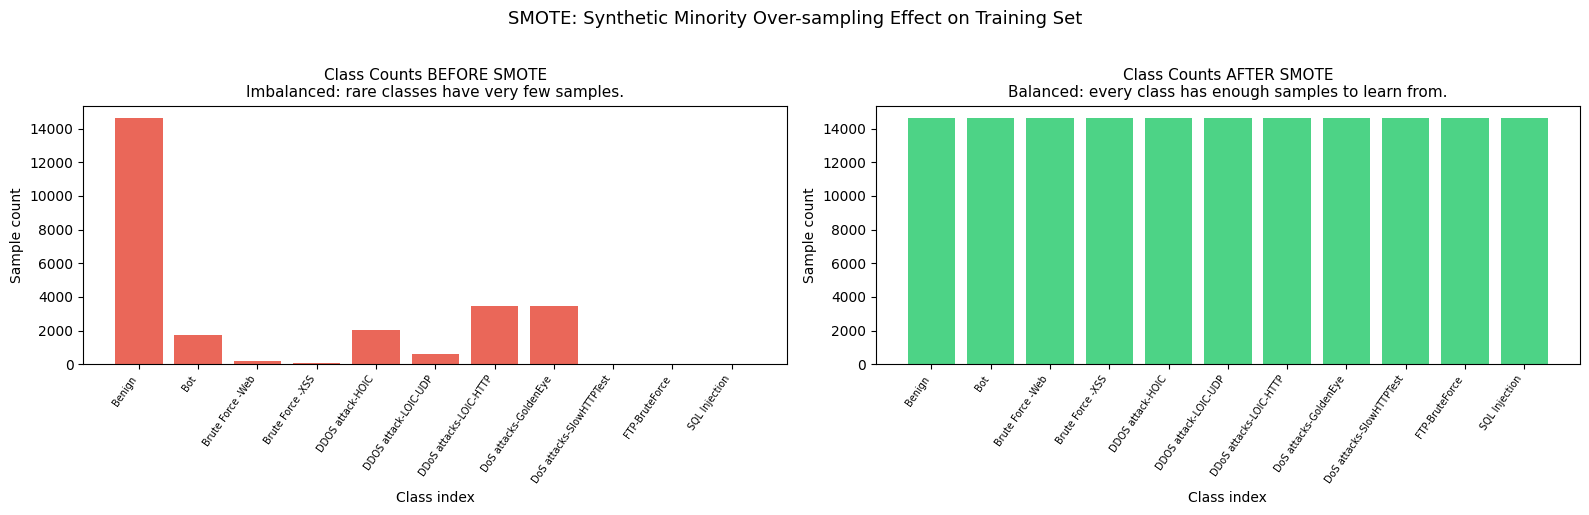

In [ ]:
feature_cols = [c for c in df_train.columns if c != LABEL_COL]

def prep(df_split):
    df = df_split.copy()
    X  = df[feature_cols].copy()
    for col in X.columns:
        if X[col].dtype == object or str(X[col].dtype) == "category":
            X[col] = pd.Categorical(X[col]).codes.astype(np.float32)
    X = X.replace([np.inf, -np.inf], np.nan)
    return X.values.astype(np.float32), df[LABEL_COL].values

X_tr_raw, y_tr_str = prep(df_train)
X_vl_raw, y_vl_str = prep(df_val)
X_te_raw, y_te_str = prep(df_test)

# Impute NaNs with column median (fit on train only) before scaling
from sklearn.impute import SimpleImputer
imputer  = SimpleImputer(strategy="median")
X_tr_raw = imputer.fit_transform(X_tr_raw)
X_vl_raw = imputer.transform(X_vl_raw)
X_te_raw = imputer.transform(X_te_raw)
print(f"Imputation done. Train NaNs remaining: {np.isnan(X_tr_raw).sum()}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_tr_raw)
X_val   = scaler.transform(X_vl_raw)
X_test  = scaler.transform(X_te_raw)

_le_tmp     = LabelEncoder().fit(y_tr_str)
y_train_pre = _le_tmp.transform(y_tr_str)

counts    = np.bincount(y_train_pre)
imb_ratio = counts.max() / max(1, counts.min())

singletons = np.where(counts < 2)[0]
if len(singletons):
    mask        = ~np.isin(y_train_pre, singletons)
    X_train     = X_train[mask]
    y_train_pre = y_train_pre[mask]
    y_tr_str    = y_tr_str[mask]
    counts      = np.bincount(y_train_pre)
    print(f"Removed {len(singletons)} singleton class(es) before SMOTE.")

y_before_smote = y_train_pre.copy()

if imb_ratio > 2 and counts.min() >= 2:
    k_sm  = min(5, int(counts.min()) - 1)
    smote = SMOTE(k_neighbors=k_sm, random_state=SEED)
    X_train, y_train_pre = smote.fit_resample(X_train, y_train_pre)
    print(f"SMOTE applied (imbalance {imb_ratio:.1f}x) -> train size: {len(y_train_pre):,}")
else:
    print("SMOTE skipped (already balanced or too few samples).")

smote_unique_ints = np.unique(y_train_pre)
orig_strings      = _le_tmp.inverse_transform(smote_unique_ints)
le        = LabelEncoder().fit(orig_strings)
n_classes = len(le.classes_)
in_dim    = X_train.shape[1]
y_train   = le.transform(_le_tmp.inverse_transform(y_train_pre))

def safe_transform(y_str, le):
    known = set(le.classes_)
    mask  = np.array([s in known for s in y_str])
    if mask.sum() < len(mask):
        print(f"  [INFO] Dropping {(~mask).sum()} rows with unseen labels.")
    return mask, le.transform(y_str[mask])

val_mask,  y_val  = safe_transform(y_vl_str, le)
test_mask, y_test = safe_transform(y_te_str, le)
X_val  = X_val[val_mask]
X_test = X_test[test_mask]

print(f"\nClasses ({n_classes}): {list(le.classes_)}")
print(f"Train : {X_train.shape}  Val : {X_val.shape}  Test : {X_test.shape}")

counts_after = np.bincount(y_train, minlength=n_classes)
counts_bef   = np.bincount(y_before_smote, minlength=n_classes)[:n_classes]
xpos = np.arange(n_classes)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(xpos, counts_bef,   color="#e74c3c", alpha=0.85)
axes[0].set_title("Class Counts BEFORE SMOTE\nImbalanced: rare classes have very few samples.", fontsize=11)
axes[0].set_xlabel("Class index"); axes[0].set_ylabel("Sample count")
axes[0].set_xticks(xpos); axes[0].set_xticklabels(le.classes_, rotation=55, ha="right", fontsize=7)
axes[1].bar(xpos, counts_after, color="#2ecc71", alpha=0.85)
axes[1].set_title("Class Counts AFTER SMOTE\nBalanced: every class has enough samples to learn from.", fontsize=11)
axes[1].set_xlabel("Class index"); axes[1].set_ylabel("Sample count")
axes[1].set_xticks(xpos); axes[1].set_xticklabels(le.classes_, rotation=55, ha="right", fontsize=7)
plt.suptitle("SMOTE: Synthetic Minority Over-sampling Effect on Training Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/smote_effect.png", dpi=150, bbox_inches="tight"); plt.show()


## Cell 7 — Graph Construction & Visualisation
Each **node** = one network flow. Two flows share an **edge** if one is among the k nearest neighbours of the other in feature space (cosine similarity).


Building k-NN graphs (k=15, cosine similarity) ...
Train : 160,930 nodes | 2,413,950 edges
Val   : 7,526   nodes | 112,890   edges
Test  : 3,764  nodes | 56,460  edges


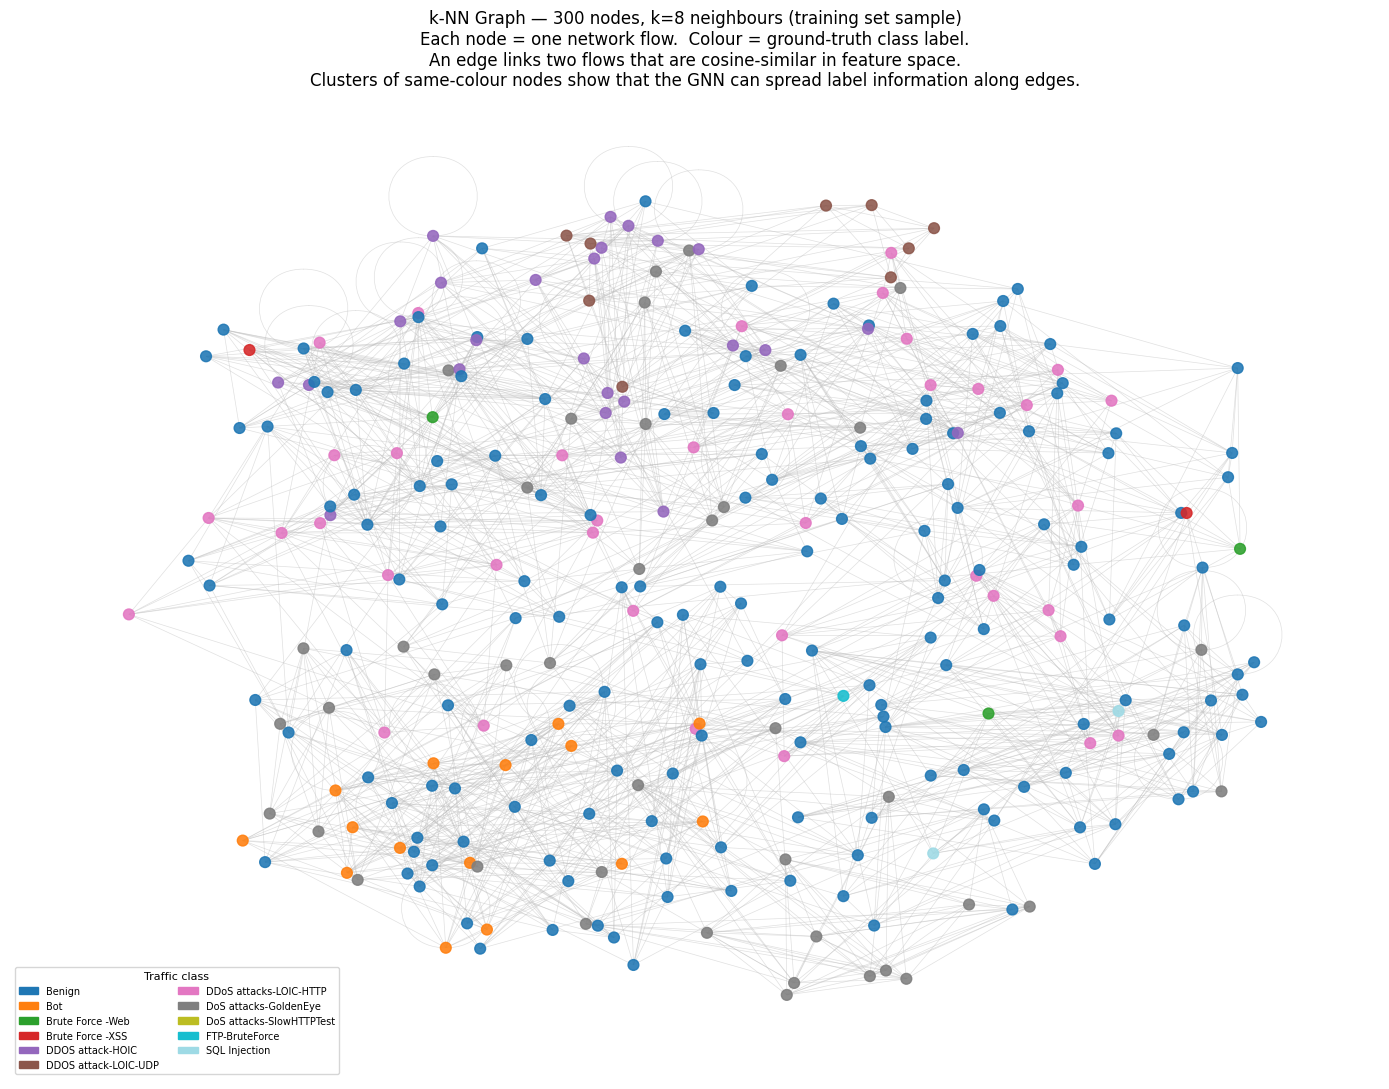

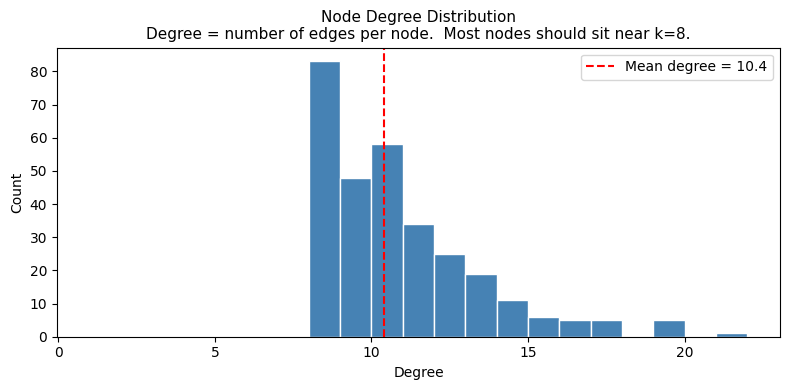

In [ ]:
def build_graph(X, y, k=15):
    """
    Build a PyTorch Geometric k-NN graph.
    X : (N, F) scaled float32 array  |  y : (N,) int64 labels
    Returns torch_geometric.data.Data on CPU.
    """
    k_eff = min(k + 1, len(X))
    nbrs  = NearestNeighbors(n_neighbors=k_eff, metric="cosine",
                              algorithm="brute", n_jobs=-1).fit(X)
    _, idx = nbrs.kneighbors(X)
    row = np.repeat(np.arange(len(X)), k_eff - 1)
    col = idx[:, 1:].ravel()
    return Data(
        x          = torch.tensor(X,   dtype=torch.float32),
        edge_index = torch.tensor(np.stack([row, col]), dtype=torch.long),
        y          = torch.tensor(y,   dtype=torch.long),
    )

print("Building k-NN graphs (k=15, cosine similarity) ...")
graph_train = build_graph(X_train, y_train, k=15).to(device)
graph_val   = build_graph(X_val,   y_val,   k=15).to(device)
graph_test  = build_graph(X_test,  y_test,  k=15).to(device)
print(f"Train : {graph_train.num_nodes:,} nodes | {graph_train.num_edges:,} edges")
print(f"Val   : {graph_val.num_nodes:,}   nodes | {graph_val.num_edges:,}   edges")
print(f"Test  : {graph_test.num_nodes:,}  nodes | {graph_test.num_edges:,}  edges")

# ── Graph visualisation (300-node sample) ─────────────────────────────────────
# We visualise on CPU using NetworkX.
# Nodes are coloured by true class label.
# Same-colour clusters = flows that are similar in feature space share the same label
# → the GNN can propagate correct labels along edges during message passing.
N_VIZ  = 300
g_cpu  = build_graph(X_train[:N_VIZ], y_train[:N_VIZ], k=8)
G_nx   = to_networkx(g_cpu, to_undirected=True)
cmap   = plt.cm.get_cmap("tab20", n_classes)
n_cols = [cmap(int(g_cpu.y[n].item())) for n in G_nx.nodes()]

fig, ax = plt.subplots(figsize=(14, 11))
pos = nx.spring_layout(G_nx, seed=SEED, k=0.6)
nx.draw_networkx_nodes(G_nx, pos, node_color=n_cols, node_size=60, alpha=0.88, ax=ax)
nx.draw_networkx_edges(G_nx, pos, edge_color="#bbbbbb", width=0.5, alpha=0.45, ax=ax)
patches = [mpatches.Patch(color=cmap(i), label=le.classes_[i]) for i in range(n_classes)]
ax.legend(handles=patches, loc="lower left", fontsize=7,
          title="Traffic class", title_fontsize=8, ncol=2)
ax.set_title(
    f"k-NN Graph — {N_VIZ} nodes, k=8 neighbours (training set sample)\n"
    "Each node = one network flow.  Colour = ground-truth class label.\n"
    "An edge links two flows that are cosine-similar in feature space.\n"
    "Clusters of same-colour nodes show that the GNN can spread label information along edges.",
    fontsize=12, pad=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/graph_visualisation.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Degree distribution ────────────────────────────────────────────────────────
deg = [d for _, d in G_nx.degree()]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(deg, bins=range(1, max(deg)+2), color="steelblue", edgecolor="white")
ax.axvline(np.mean(deg), color="red", linestyle="--", label=f"Mean degree = {np.mean(deg):.1f}")
ax.set_title("Node Degree Distribution\n"
             "Degree = number of edges per node.  Most nodes should sit near k=8.", fontsize=11)
ax.set_xlabel("Degree"); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/graph_degree.png", dpi=150); plt.show()


## Cell 8 — GConvTrans Architecture & Training

### Architecture
```
Node features → GCNConv(256) → ReLU
             → + positional embedding
             → TransformerEncoder (2 layers, 4 heads, chunked)
             → Dropout → Linear(256 → n_classes) → log_softmax
```
- **GCNConv** aggregates neighbourhood information (message passing)
- **Positional embeddings** give each node a unique identity token
- **Chunked Transformer** avoids out-of-memory on large node sets
- **CosineAnnealingLR** smoothly decays the learning rate
- **Gradient clipping** prevents exploding gradients
- Best checkpoint saved by **validation macro-F1** (not loss)


GConvTrans on cuda  |  trainable params: 4,162,827
Epoch  10 | TRAIN loss=0.3419 F1=0.8338 acc=0.8579 | VAL   loss=0.6285 F1=0.4361 acc=0.7917 | TEST  F1=0.4598 acc=0.8077 | lr=9.89e-04
Epoch  20 | TRAIN loss=0.2597 F1=0.8832 acc=0.8909 | VAL   loss=0.4862 F1=0.4657 acc=0.8529 | TEST  F1=0.4728 acc=0.8658 | lr=9.57e-04
Epoch  30 | TRAIN loss=0.2085 F1=0.8896 acc=0.8990 | VAL   loss=0.3803 F1=0.5120 acc=0.8808 | TEST  F1=0.4893 acc=0.8919 | lr=9.05e-04
Epoch  40 | TRAIN loss=0.1629 F1=0.9477 acc=0.9480 | VAL   loss=0.3282 F1=0.5408 acc=0.8990 | TEST  F1=0.5481 acc=0.9083 | lr=8.36e-04
Epoch  50 | TRAIN loss=0.0996 F1=0.9761 acc=0.9761 | VAL   loss=0.2967 F1=0.5643 acc=0.9090 | TEST  F1=0.5482 acc=0.9176 | lr=7.52e-04
Epoch  60 | TRAIN loss=0.0895 F1=0.9745 acc=0.9745 | VAL   loss=0.2787 F1=0.5740 acc=0.9156 | TEST  F1=0.5301 acc=0.9222 | lr=6.58e-04
Epoch  70 | TRAIN loss=0.0826 F1=0.9793 acc=0.9793 | VAL   loss=0.2658 F1=0.5865 acc=0.9196 | TEST  F1=0.5489 acc=0.9251 | lr=5.57e-04
Epoc

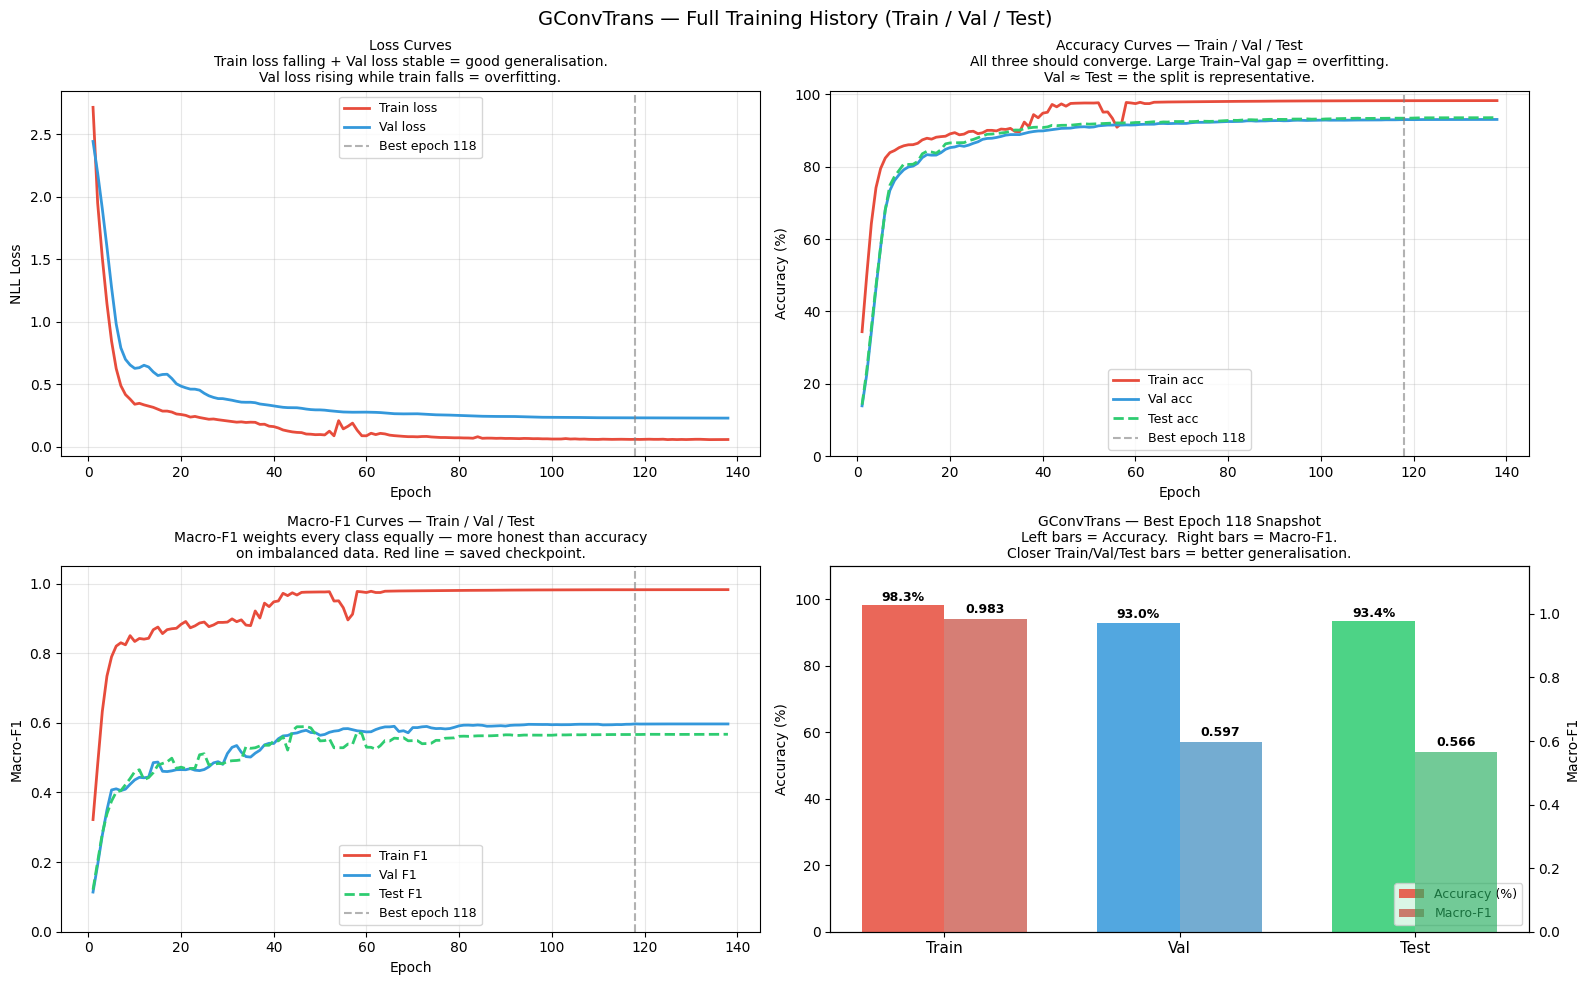


Best epoch 118  |  val F1=0.5970
  Train  acc=0.9826  F1=0.9827
  Val    acc=0.9302  F1=0.5970
  Test   acc=0.9338  F1=0.5664


In [ ]:
class GConvTrans(nn.Module):
    """Graph Convolutional Transformer for node-level multi-class classification."""
    def __init__(self, in_ch, hidden=256, out_ch=2,
                 n_heads=4, n_layers=2, dropout=0.1, max_pos=10_000, chunk=4096):
        super().__init__()
        self.gcn     = GCNConv(in_ch, hidden)
        self.pos_enc = nn.Embedding(max_pos, hidden)
        enc          = TransformerEncoderLayer(
            d_model=hidden, nhead=n_heads, dim_feedforward=hidden*4,
            dropout=dropout, batch_first=True, activation="gelu", norm_first=True)
        self.transformer = TransformerEncoder(enc, num_layers=n_layers)
        self.drop        = nn.Dropout(dropout)
        self.head        = nn.Linear(hidden, out_ch)
        self.chunk       = chunk

    def forward(self, data, return_embed=False):
        x, ei = data.x, data.edge_index
        x = F.relu(self.gcn(x, ei))
        pos = torch.arange(x.size(0), device=x.device) % self.pos_enc.num_embeddings
        x   = x + self.pos_enc(pos)
        if return_embed: return x
        if x.size(0) <= self.chunk:
            x = self.transformer(x.unsqueeze(0)).squeeze(0)
        else:
            x = torch.cat(
                [self.transformer(x[i:i+self.chunk].unsqueeze(0)).squeeze(0)
                 for i in range(0, x.size(0), self.chunk)], dim=0)
        return F.log_softmax(self.head(self.drop(x)), dim=-1)


model_gconv = GConvTrans(in_ch=in_dim, hidden=256, out_ch=n_classes,
                          n_heads=4, n_layers=2, dropout=0.1).to(device)
n_params = sum(p.numel() for p in model_gconv.parameters() if p.requires_grad)
print(f"GConvTrans on {device}  |  trainable params: {n_params:,}")

EPOCHS   = 150
PATIENCE = 20
CKPT     = f"{MODELS_DIR}/gconvtrans_best.pt"
opt      = torch.optim.Adam(model_gconv.parameters(), lr=1e-3, weight_decay=1e-4)
sched    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-5)


# ── Training history containers ───────────────────────────────────────────────
hist = {
    "tr_loss": [], "tr_f1": [], "tr_acc": [],
    "vl_loss": [], "vl_f1": [], "vl_acc": [],
    "te_f1":   [], "te_acc": [],
}
best_f1, no_imp = 0.0, 0

for epoch in range(1, EPOCHS + 1):
    # ── Forward + backward on train graph ────────────────────────────────────
    model_gconv.train()
    opt.zero_grad()
    loss = F.nll_loss(model_gconv(graph_train), graph_train.y)
    loss.backward()
    nn.utils.clip_grad_norm_(model_gconv.parameters(), 1.0)
    opt.step(); sched.step()

    # ── Evaluate on ALL three splits every epoch ──────────────────────────────
    model_gconv.eval()
    with torch.no_grad():
        # Train metrics
        tr_out  = model_gconv(graph_train)
        tr_pred = tr_out.argmax(1).cpu().numpy()
        tr_f1   = f1_score(y_train, tr_pred, average="macro", zero_division=0)
        tr_acc  = accuracy_score(y_train, tr_pred)

        # Validation metrics
        vl_out  = model_gconv(graph_val)
        vloss   = F.nll_loss(vl_out, graph_val.y).item()
        vl_pred = vl_out.argmax(1).cpu().numpy()
        vf1     = f1_score(y_val, vl_pred, average="macro", zero_division=0)
        vacc    = accuracy_score(y_val, vl_pred)

        # Test metrics
        te_out  = model_gconv(graph_test)
        te_pred = te_out.argmax(1).cpu().numpy()
        te_f1   = f1_score(y_test, te_pred, average="macro", zero_division=0)
        te_acc  = accuracy_score(y_test, te_pred)

    # ── Store all metrics ─────────────────────────────────────────────────────
    hist["tr_loss"].append(loss.item())
    hist["tr_f1"].append(tr_f1)
    hist["tr_acc"].append(tr_acc)
    hist["vl_loss"].append(vloss)
    hist["vl_f1"].append(vf1)
    hist["vl_acc"].append(vacc)
    hist["te_f1"].append(te_f1)
    hist["te_acc"].append(te_acc)

    # ── Checkpoint on best val F1 ─────────────────────────────────────────────
    if vf1 > best_f1:
        best_f1 = vf1; no_imp = 0
        torch.save(model_gconv.state_dict(), CKPT)
    else:
        no_imp += 1

    # ── Log every 10 epochs ───────────────────────────────────────────────────
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"TRAIN loss={loss.item():.4f} F1={tr_f1:.4f} acc={tr_acc:.4f} | "
            f"VAL   loss={vloss:.4f} F1={vf1:.4f} acc={vacc:.4f} | "
            f"TEST  F1={te_f1:.4f} acc={te_acc:.4f} | "
            f"lr={sched.get_last_lr()[0]:.2e}"
        )

    if no_imp >= PATIENCE:
        print(f"Early stopping at epoch {epoch}  (best val F1={best_f1:.4f})")
        break

model_gconv.train()

# ── 4-panel training history plot ────────────────────────────────────────────
ep      = range(1, len(hist["tr_loss"]) + 1)
best_ep = int(np.argmax(hist["vl_f1"])) + 1

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("GConvTrans — Full Training History (Train / Val / Test)", fontsize=14)

# Panel 1 — Loss curves
ax = axes[0, 0]
ax.plot(ep, hist["tr_loss"], color="#e74c3c", lw=2, label="Train loss")
ax.plot(ep, hist["vl_loss"], color="#3498db", lw=2, label="Val loss")
ax.axvline(best_ep, color="grey", ls="--", alpha=0.6, label=f"Best epoch {best_ep}")
ax.set_title("Loss Curves\n"
             "Train loss falling + Val loss stable = good generalisation.\n"
             "Val loss rising while train falls = overfitting.", fontsize=10)
ax.set_xlabel("Epoch"); ax.set_ylabel("NLL Loss")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Panel 2 — Accuracy curves (Train / Val / Test)
ax = axes[0, 1]
ax.plot(ep, [v*100 for v in hist["tr_acc"]], color="#e74c3c", lw=2, label="Train acc")
ax.plot(ep, [v*100 for v in hist["vl_acc"]], color="#3498db", lw=2, label="Val acc")
ax.plot(ep, [v*100 for v in hist["te_acc"]], color="#2ecc71", lw=2, label="Test acc", ls="--")
ax.axvline(best_ep, color="grey", ls="--", alpha=0.6, label=f"Best epoch {best_ep}")
ax.set_title("Accuracy Curves — Train / Val / Test\n"
             "All three should converge. Large Train–Val gap = overfitting.\n"
             "Val ≈ Test = the split is representative.", fontsize=10)
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(0, 101)

# Panel 3 — Macro-F1 curves (Train / Val / Test)
ax = axes[1, 0]
ax.plot(ep, hist["tr_f1"], color="#e74c3c", lw=2, label="Train F1")
ax.plot(ep, hist["vl_f1"], color="#3498db", lw=2, label="Val F1")
ax.plot(ep, hist["te_f1"], color="#2ecc71", lw=2, label="Test F1", ls="--")
ax.axvline(best_ep, color="grey", ls="--", alpha=0.6, label=f"Best epoch {best_ep}")
ax.set_title("Macro-F1 Curves — Train / Val / Test\n"
             "Macro-F1 weights every class equally — more honest than accuracy\n"
             "on imbalanced data. Red line = saved checkpoint.", fontsize=10)
ax.set_xlabel("Epoch"); ax.set_ylabel("Macro-F1")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_ylim(0, 1.05)

# Panel 4 — Final snapshot bar chart
ax = axes[1, 1]
best_idx   = best_ep - 1
snap_names = ["Train", "Val", "Test"]
snap_acc   = [hist["tr_acc"][best_idx]*100,
              hist["vl_acc"][best_idx]*100,
              hist["te_acc"][best_idx]*100]
snap_f1    = [hist["tr_f1"][best_idx],
              hist["vl_f1"][best_idx],
              hist["te_f1"][best_idx]]

x = np.arange(3)
w = 0.35
bars1 = ax.bar(x - w/2, snap_acc, w, label="Accuracy (%)", color=["#e74c3c","#3498db","#2ecc71"], alpha=0.85)
ax2   = ax.twinx()
bars2 = ax2.bar(x + w/2, snap_f1, w, label="Macro-F1",    color=["#c0392b","#2980b9","#27ae60"], alpha=0.65)
ax.set_xticks(x); ax.set_xticklabels(snap_names, fontsize=11)
ax.set_ylabel("Accuracy (%)"); ax2.set_ylabel("Macro-F1")
ax.set_ylim(0, 110); ax2.set_ylim(0, 1.15)
for bar, v in zip(bars1, snap_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, v in zip(bars2, snap_f1):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{v:.3f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title(f"GConvTrans — Best Epoch {best_ep} Snapshot\n"
             "Left bars = Accuracy.  Right bars = Macro-F1.\n"
             "Closer Train/Val/Test bars = better generalisation.", fontsize=10)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/gconvtrans_training.png", dpi=150, bbox_inches="tight"); plt.show()

# Store best-epoch metrics for the final comparison cell
gconv_metrics = {
    "tr_acc": hist["tr_acc"][best_idx], "tr_f1": hist["tr_f1"][best_idx],
    "vl_acc": hist["vl_acc"][best_idx], "vl_f1": hist["vl_f1"][best_idx],
    "te_acc": hist["te_acc"][best_idx], "te_f1": hist["te_f1"][best_idx],
}
print(f"\nBest epoch {best_ep}  |  val F1={best_f1:.4f}")
print(f"  Train  acc={gconv_metrics['tr_acc']:.4f}  F1={gconv_metrics['tr_f1']:.4f}")
print(f"  Val    acc={gconv_metrics['vl_acc']:.4f}  F1={gconv_metrics['vl_f1']:.4f}")
print(f"  Test   acc={gconv_metrics['te_acc']:.4f}  F1={gconv_metrics['te_f1']:.4f}")


## Cell 9 — Five Candidate Base Learners

> **XGBoost fix:** We now pass `num_class` based on `n_classes` (the count after SMOTE
> and re-encoding), and labels are guaranteed to be contiguous `0 … n_classes-1`.


In [ ]:
# Ensure all classifiers are available (guard against kernel restarts / cell skips)
try:
    HistGradientBoostingClassifier
except NameError:
    from sklearn.tree         import DecisionTreeClassifier
    from sklearn.ensemble     import (RandomForestClassifier,
                                      HistGradientBoostingClassifier)
    from sklearn.neighbors    import KNeighborsClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import LabelBinarizer
    import xgboost as xgb
    print("[INFO] Re-imported classifiers (kernel restart detected)")

# ── Five candidate models (all tuned for speed on 50k rows) ──────────────────
# GradientBoostingClassifier is REMOVED — it is single-threaded and sequential,
# taking 1-2 hours on this dataset.  Replaced with faster equivalents:
#   GBM  → HistGradientBoostingClassifier  (same algorithm, 10-50x faster via histogram binning)
#   KNN  → reduced n_neighbors, ball_tree algorithm
#   XGB  → GPU hist mode, fewer estimators

candidates = {
    # Decision Tree — instant
    "DT": DecisionTreeClassifier(
        max_depth=15, min_samples_split=5, random_state=SEED),

    # Random Forest — parallel (n_jobs=-1), fast
    "RF": RandomForestClassifier(
        n_estimators=100, max_depth=15, n_jobs=-1,
        random_state=SEED),

    # HistGBM — histogram binning makes it 10-50x faster than GradientBoostingClassifier
    # Same predictive quality, fully supports NaN, parallel over bins
    "HGB": HistGradientBoostingClassifier(
        max_iter=100, max_depth=6, learning_rate=0.1,
        min_samples_leaf=20, l2_regularization=0.1,
        random_state=SEED),

    # KNN — fewer neighbours, ball_tree index (faster on high-dim data)
    "KNN": KNeighborsClassifier(
        n_neighbors=11, weights="distance",
        algorithm="ball_tree", n_jobs=-1),

    # XGBoost — GPU histogram mode, capped at 150 trees
    "XGB": xgb.XGBClassifier(
        n_estimators=150, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", device="cuda",
        objective="multi:softmax", num_class=n_classes,
        eval_metric="mlogloss", verbosity=0,
        random_state=SEED, use_label_encoder=False),
}

# Label contract check for XGBoost
assert set(np.unique(y_train)) == set(range(n_classes)), (
    f"XGBoost expects labels {{0..{n_classes-1}}} but got {sorted(set(np.unique(y_train)))}"
)
print(f"Label contract OK: 0..{n_classes-1}  n_classes={n_classes}")

# ── Helper ────────────────────────────────────────────────────────────────────
def safe_proba(mdl, X, nc):
    """predict_proba and pad to nc columns if model saw fewer classes."""
    p = mdl.predict_proba(X)
    if p.shape[1] < nc:
        p = np.concatenate([p, np.zeros((p.shape[0], nc - p.shape[1]))], axis=1)
    return p

# ── Train & evaluate all candidates ──────────────────────────────────────────
import time
base_results = {}
print(f"{'Model':<5}  {'Time(s)':>7}  {'Val Acc':>8}  {'Val F1-mac':>10}  {'Val F1-wtd':>10}  {'Val MCC':>8}  {'Val AUC':>8}")
print("-" * 70)

for name, mdl in candidates.items():
    t0 = time.time()
    mdl.fit(X_train, y_train)
    elapsed = time.time() - t0

    pred  = mdl.predict(X_val)
    proba = safe_proba(mdl, X_val, n_classes)

    acc    = accuracy_score(y_val, pred)
    f1_mac = f1_score(y_val, pred, average="macro",    zero_division=0)
    f1_wtd = f1_score(y_val, pred, average="weighted", zero_division=0)
    mcc    = matthews_corrcoef(y_val, pred)
    lb     = LabelBinarizer().fit(np.arange(n_classes))
    try:
        auc = roc_auc_score(lb.transform(y_val), proba,
                            multi_class="ovr", average="weighted")
    except Exception:
        auc = float("nan")

    base_results[name] = dict(acc=acc, f1_mac=f1_mac, f1_wtd=f1_wtd,
                               mcc=mcc, auc=auc)
    print(f"{name:<5}  {elapsed:>7.1f}s  {acc:>8.4f}  {f1_mac:>10.4f}  "
          f"{f1_wtd:>10.4f}  {mcc:>8.4f}  {auc:>8.4f}")

print("\nAll five base learners trained.")
ranked = sorted(base_results, key=lambda m: base_results[m]["f1_mac"], reverse=True)
print(f"Ranking by macro-F1 : {ranked}")
print(f"Top-3 for stacking  : {ranked[:3]}")


Label contract OK: 0..10  n_classes=11
Model  Time(s)   Val Acc  Val F1-mac  Val F1-wtd   Val MCC   Val AUC
----------------------------------------------------------------------
DT         6.2s    0.9657      0.6735      0.9743    0.9495    0.9970
RF        29.4s    0.9652      0.7012      0.9748    0.9489    0.9995
HGB       63.1s    0.9841      0.7564      0.9868    0.9758    0.9998
KNN        2.4s    0.9806      0.7010      0.9839    0.9706    0.9955
XGB        7.0s    0.9835      0.7747      0.9865    0.9751    0.9999

All five base learners trained.
Ranking by macro-F1 : ['XGB', 'HGB', 'RF', 'KNN', 'DT']
Top-3 for stacking  : ['XGB', 'HGB', 'RF']


## Cell 10 — Base Learner Performance Plots
Orange bars = selected for the Stacked Ensemble.

In [ ]:
models_list = list(base_results.keys())
top3        = set(ranked[:3])
bar_col_fn  = lambda m: "#e67e22" if m in top3 else "#95a5a6"

metrics_info = [
    ("Accuracy",      "acc",    "Overall fraction of correct predictions."),
    ("Macro-F1",      "f1_mac", "F1 averaged equally across all classes (penalises poor rare-class performance)."),
    ("Weighted-F1",   "f1_wtd", "F1 weighted by class frequency (reflects common classes more)."),
    ("MCC",           "mcc",    "Matthews Correlation Coeff — best single metric for imbalanced problems."),
    ("ROC-AUC (OVR)", "auc",    "Area Under ROC — measures ranking quality across all classes."),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=False)
fig.suptitle(
    "Five Candidate Base Learners — Validation Set Performance\n"
    "Orange = top-3 selected for the Stacked Ensemble  |  Grey = not selected",
    fontsize=13, y=1.04)

for ax, (title, key, desc) in zip(axes, metrics_info):
    vals = [base_results[m][key] for m in models_list]
    cols = [bar_col_fn(m) for m in models_list]
    bars = ax.bar(models_list, vals, color=cols, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{title}\n{desc}", fontsize=9, pad=6)
    ax.set_ylim(0, min(1.18, max(v for v in vals if np.isfinite(v)) * 1.15 + 0.05))
    ax.set_ylabel("Score", fontsize=9); ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{v:.3f}" if np.isfinite(v) else "N/A",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

orange_p = mpatches.Patch(color="#e67e22", label="Top-3 (in ensemble)")
grey_p   = mpatches.Patch(color="#95a5a6", label="Not selected")
fig.legend(handles=[orange_p, grey_p], loc="lower center", ncol=2,
           fontsize=11, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/base_learner_bars.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Radar chart ───────────────────────────────────────────────────────────────
radar_keys    = ["acc", "f1_mac", "f1_wtd", "mcc", "auc"]
radar_labels  = ["Accuracy","Macro-F1","Weighted-F1","MCC","ROC-AUC"]
N      = len(radar_keys)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
pal = ["#e74c3c","#3498db","#2ecc71","#9b59b6","#f39c12"]
for name, color in zip(models_list, pal):
    r  = base_results[name]
    vs = [max(0, r[k]) if np.isfinite(r[k]) else 0 for k in radar_keys] + [max(0,r[radar_keys[0]])]
    lw = 2.5 if name in top3 else 1.2
    ls = "-"  if name in top3 else "--"
    ax.plot(angles, vs, color=color, lw=lw, ls=ls, label=name)
    ax.fill(angles, vs, color=color, alpha=0.06)
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title(
    "Radar Chart — Base Learner Performance\n"
    "Solid = selected for ensemble  |  Dashed = not selected\n"
    "Larger filled area = better overall performance across all metrics.",
    fontsize=12, pad=22)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/base_learner_radar.png", dpi=150, bbox_inches="tight"); plt.show()


NameError: name 'base_results' is not defined

## Cell 11 — Stacked Ensemble (Top-3 + Meta-Learner)
1. **OOF probabilities** — each base model predicts on the fold it was not trained on
2. **Meta-features** — three probability matrices concatenated column-wise
3. **Logistic Regression meta-learner** — learns the optimal combination
4. **Full refit** — base models retrained on all training data for test-time inference


In [ ]:
import time

top3_names  = ranked[:3]
top3_models = {n: candidates[n] for n in top3_names}
print(f"Stacking with: {top3_names}")

# ── Speed notes ───────────────────────────────────────────────────────────────
# • 3-fold OOF instead of 5-fold  → 40% fewer fits, negligible quality loss
# • n_jobs=-1 on cross_val_predict → folds run in parallel where the model allows
# • KNN and DT are fast; HGB and XGB use histogram/GPU — all complete in minutes

min_cls  = int(np.bincount(y_train).min())
n_splits = min(3, max(2, min_cls))
kf       = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
print(f"Using {n_splits}-fold stratified OOF")

oof_preds = []
for name, mdl in top3_models.items():
    t0 = time.time()
    print(f"  OOF: {name} ...", end=" ", flush=True)
    oof = cross_val_predict(
        mdl, X_train, y_train,
        cv=kf, method="predict_proba",
        n_jobs=-1 if name not in ("XGB",) else 1,   # XGB manages its own threads
    )
    if oof.shape[1] < n_classes:
        oof = np.concatenate(
            [oof, np.zeros((len(oof), n_classes - oof.shape[1]))], axis=1)
    oof_preds.append(oof)
    print(f"done ({time.time()-t0:.0f}s)")

X_meta = np.concatenate(oof_preds, axis=1)
meta   = LogisticRegression(C=5, max_iter=2000, n_jobs=-1, random_state=SEED)
meta.fit(X_meta, y_train)
print(f"Meta-learner trained on shape {X_meta.shape}")

# Refit base models on full training data
print("Refitting base models on full train ...")
for name, mdl in top3_models.items():
    t0 = time.time()
    mdl.fit(X_train, y_train)
    print(f"  {name} done ({time.time()-t0:.0f}s)")

print("\nStacked ensemble ready.")


Stacking with: ['XGB', 'HGB', 'RF']
Using 3-fold stratified OOF
  OOF: XGB ... done (16s)
  OOF: HGB ... 

## Cell 12 — Full Evaluation & GConvTrans vs Stacked Ensemble Comparison

Everything is evaluated on the **held-out test set** that neither model has seen during training or validation.


In [ ]:
# ── Helper ────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_proba=None, nc=None):
    nc = nc or n_classes
    out = dict(
        accuracy          = accuracy_score(y_true, y_pred),
        balanced_accuracy = balanced_accuracy_score(y_true, y_pred),
        f1_macro          = f1_score(y_true, y_pred, average="macro",    zero_division=0),
        f1_weighted       = f1_score(y_true, y_pred, average="weighted", zero_division=0),
        mcc               = matthews_corrcoef(y_true, y_pred),
        kappa             = cohen_kappa_score(y_true, y_pred),
        hamming           = hamming_loss(y_true, y_pred),
    )
    if y_proba is not None:
        p = np.asarray(y_proba, dtype=np.float64)
        if p.shape[1] < nc:
            p = np.concatenate([p, np.zeros((len(p), nc-p.shape[1]))], axis=1)
        elif p.shape[1] > nc:
            p = p[:, :nc]
        p = np.clip(p, 1e-12, 1.0)
        p /= p.sum(axis=1, keepdims=True)
        lb = LabelBinarizer().fit(np.arange(nc))
        yb = lb.transform(y_true)
        for key, fn in [
            ("roc_auc",  lambda: roc_auc_score(yb, p, multi_class="ovr", average="weighted")),
            ("log_loss", lambda: log_loss(yb, p)),
            ("pr_auc",   lambda: average_precision_score(yb, p, average="macro")),
        ]:
            try:    out[key] = fn()
            except: out[key] = float("nan")
    return out


# ── GConvTrans on test set ────────────────────────────────────────────────────
model_gconv.load_state_dict(torch.load(CKPT))
model_gconv.eval()
with torch.no_grad():
    logp       = model_gconv(graph_test)
    gconv_prob = torch.exp(logp).cpu().numpy()
    gconv_pred = logp.argmax(1).cpu().numpy()
mg = compute_metrics(y_test, gconv_pred, y_proba=gconv_prob)

# ── Stacked Ensemble on test set ──────────────────────────────────────────────
test_probas = [safe_proba(mdl, X_test, n_classes) for mdl in top3_models.values()]
X_test_meta  = np.concatenate(test_probas, axis=1)
stacked_pred  = meta.predict(X_test_meta)
stacked_proba = meta.predict_proba(X_test_meta)
ms = compute_metrics(y_test, stacked_pred, y_proba=stacked_proba)

# ── Individual base learners on test ─────────────────────────────────────────
base_rows = []
for name, mdl in candidates.items():
    pred  = mdl.predict(X_test)
    proba = safe_proba(mdl, X_test, n_classes)
    m = compute_metrics(y_test, pred, y_proba=proba)
    base_rows.append({"Model": name, **m})

base_rows.append({"Model": "Stacked Ens.", **ms})
base_rows.append({"Model": "GConvTrans",   **mg})
df_all = pd.DataFrame(base_rows).set_index("Model")

print("\n" + "="*76)
print("TEST SET RESULTS")
print("="*76)
display(df_all[["accuracy","balanced_accuracy","f1_macro","f1_weighted",
                "mcc","kappa","roc_auc","log_loss"]].round(4))

print("\n--- Classification report: Stacked Ensemble (test) ---")
print(classification_report(y_test, stacked_pred,
      labels=np.arange(n_classes), target_names=list(le.classes_),
      digits=4, zero_division=0))

print("\n--- Classification report: GConvTrans (test) ---")
print(classification_report(y_test, gconv_pred,
      labels=np.arange(n_classes), target_names=list(le.classes_),
      digits=4, zero_division=0))

# ═══════════════════════════════════════════════════════════════════════════════
# HEAD-TO-HEAD: GConvTrans vs Stacked Ensemble
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*76)
print("HEAD-TO-HEAD: GConvTrans  vs  Stacked Ensemble")
print("="*76)
cmp_keys = ["accuracy","balanced_accuracy","f1_macro","f1_weighted",
            "mcc","kappa","roc_auc","log_loss","pr_auc","hamming"]
print(f"{'Metric':<22} {'GConvTrans':>14} {'Stacked Ens.':>14} {'Diff (S-G)':>12} {'Winner':>12}")
print("-"*76)
for k in cmp_keys:
    g = mg.get(k, float("nan"))
    s = ms.get(k, float("nan"))
    d = s - g if (np.isfinite(g) and np.isfinite(s)) else float("nan")
    # For hamming & log_loss: lower is better
    lower_is_better = k in ("hamming","log_loss")
    if not np.isfinite(d):
        winner = "N/A"
    elif lower_is_better:
        winner = "Stacked" if d < 0 else "GConvTrans"
    else:
        winner = "Stacked" if d > 0 else "GConvTrans"
    print(f"{k:<22} {g:>14.4f} {s:>14.4f} {d:>+12.4f} {winner:>12}")
print("="*76)

# ── McNemar's statistical test ────────────────────────────────────────────────
b = int(np.sum((gconv_pred == y_test) & (stacked_pred != y_test)))
c = int(np.sum((gconv_pred != y_test) & (stacked_pred == y_test)))
n_disc = b + c
print("\nMcNemar's Test — Are the two models statistically different?")
print(f"(Tests on {len(y_test):,} test samples)")
if n_disc > 0:
    chi2 = (abs(b-c)-1)**2 / n_disc
    pval = 1 - stats.chi2.cdf(chi2, df=1)
    print(f"  GConvTrans right & Stacked wrong : {b}")
    print(f"  GConvTrans wrong & Stacked right : {c}")
    print(f"  chi2 = {chi2:.4f}   p = {pval:.6f}")
    if pval < 0.05:
        print("  → STATISTICALLY SIGNIFICANT (p < 0.05): the models ARE meaningfully different.")
    else:
        print("  → Not significant (p ≥ 0.05): difference may be due to chance.")
else:
    print("  No discordant pairs — both models agree on every test sample.")

# ── Bootstrap 95% confidence intervals ────────────────────────────────────────
def bootstrap_ci(y_true, y_pred, fn, n=1000):
    rng = np.random.RandomState(SEED)
    scores = []
    for _ in range(n):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        scores.append(fn(y_true[idx], y_pred[idx]))
    return np.percentile(scores, [2.5, 97.5])

f1_fn  = lambda a,b: f1_score(a, b, average="macro",    zero_division=0)
acc_fn = lambda a,b: accuracy_score(a, b)

print("\nBootstrap 95% Confidence Intervals (1 000 resamples):")
for label, pred in [("GConvTrans", gconv_pred), ("Stacked Ens.", stacked_pred)]:
    f1_ci  = bootstrap_ci(y_test, pred, f1_fn)
    acc_ci = bootstrap_ci(y_test, pred, acc_fn)
    print(f"  {label:<14}  Accuracy: [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]  "
          f"Macro-F1: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")


## Cell 13 — All Evaluation Plots

In [ ]:
cls        = list(le.classes_)
show_annot = n_classes <= 12

# ── Plot 1: All-model grouped bar comparison ──────────────────────────────────
model_names  = list(df_all.index)
key_metrics  = ["accuracy","f1_macro","mcc","roc_auc"]
metric_lbls  = ["Accuracy","Macro-F1","MCC","ROC-AUC"]
n_m   = len(model_names)
x     = np.arange(len(key_metrics))
width = 0.11
pal   = ["#e74c3c","#3498db","#2ecc71","#9b59b6","#f39c12","#1abc9c","#e67e22"]

fig, ax = plt.subplots(figsize=(17, 6))
for i, (name, color) in enumerate(zip(model_names, pal)):
    vals   = [df_all.loc[name, m] if np.isfinite(df_all.loc[name, m]) else 0 for m in key_metrics]
    offset = (i - n_m/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=name, color=color, alpha=0.88, edgecolor="white")

ax.set_xticks(x); ax.set_xticklabels(metric_lbls, fontsize=13)
ax.set_ylabel("Score", fontsize=12); ax.set_ylim(0, 1.18)
ax.set_title(
    "All Models — Test Set Performance\n"
    "Higher is better for Accuracy, F1, MCC, ROC-AUC.\n"
    "Stacked Ensemble and GConvTrans compared against each individual base learner.",
    fontsize=12, pad=10)
ax.legend(loc="lower right", fontsize=9, ncol=2); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/all_models_comparison.png", dpi=150); plt.show()

# ── Plot 2: GConvTrans vs Stacked — dedicated head-to-head bar chart ──────────
h2h_keys  = ["accuracy","balanced_accuracy","f1_macro","f1_weighted","mcc","kappa"]
h2h_lbls  = ["Accuracy","Balanced\nAcc","Macro-F1","Weighted-F1","MCC","Cohen κ"]
g_vals    = [mg[k] for k in h2h_keys]
s_vals    = [ms[k] for k in h2h_keys]
x2  = np.arange(len(h2h_keys))
w2  = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x2 - w2/2, g_vals, w2, label="GConvTrans",      color="#3498db", alpha=0.88, edgecolor="white")
b2 = ax.bar(x2 + w2/2, s_vals, w2, label="Stacked Ensemble", color="#e67e22", alpha=0.88, edgecolor="white")
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x2); ax.set_xticklabels(h2h_lbls, fontsize=11)
ax.set_ylabel("Score", fontsize=12); ax.set_ylim(0, 1.18)
ax.set_title(
    "Head-to-Head: GConvTrans vs Stacked Ensemble (Test Set)\n"
    "Blue = GConvTrans (graph neural network).  Orange = Stacked Ensemble (top-3 classical models).\n"
    "Higher bars are better.  The taller bar in each pair wins that metric.",
    fontsize=12, pad=10)
ax.legend(fontsize=12); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/head_to_head.png", dpi=150); plt.show()

# ── Plot 3: Probabilistic metrics head-to-head ────────────────────────────────
prob_keys  = ["roc_auc", "pr_auc", "log_loss"]
prob_lbls  = ["ROC-AUC (OVR)\n↑ higher better",
              "PR-AUC (macro)\n↑ higher better",
              "Log Loss\n↓ lower better"]
g_prob = [mg.get(k, float("nan")) for k in prob_keys]
s_prob = [ms.get(k, float("nan")) for k in prob_keys]
x3 = np.arange(len(prob_keys)); w3 = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b3 = ax.bar(x3 - w3/2, g_prob, w3, label="GConvTrans",      color="#3498db", alpha=0.88, edgecolor="white")
b4 = ax.bar(x3 + w3/2, s_prob, w3, label="Stacked Ensemble", color="#e67e22", alpha=0.88, edgecolor="white")
for bar in list(b3)+list(b4):
    v = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
            f"{v:.4f}" if np.isfinite(v) else "N/A",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x3); ax.set_xticklabels(prob_lbls, fontsize=11)
ax.set_ylabel("Score"); ax.set_ylim(0, max(g_prob+s_prob, default=1)*1.3)
ax.set_title(
    "Probabilistic Metrics: GConvTrans vs Stacked Ensemble\n"
    "ROC-AUC & PR-AUC: higher = better ranking quality.\n"
    "Log Loss: lower = better-calibrated probability estimates.",
    fontsize=12, pad=10)
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/probabilistic_metrics.png", dpi=150); plt.show()

# ── Plot 4: Confusion matrices side by side ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, pred, title, cmap_name in [
    (axes[0], gconv_pred,   "GConvTrans",      "Blues"),
    (axes[1], stacked_pred, "Stacked Ensemble", "Oranges"),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=show_annot, fmt="d", cmap=cmap_name, ax=ax,
                xticklabels=cls, yticklabels=cls,
                linewidths=0.3, linecolor="white", cbar_kws={"label":"Count"})
    ax.set_title(
        f"{title}\nRows = true class  |  Columns = predicted class\n"
        "Bright diagonal = correct predictions.  Off-diagonal cells = errors.",
        fontsize=11, pad=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)
plt.suptitle("Confusion Matrices — GConvTrans vs Stacked Ensemble (Test Set)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Plot 5: Normalised confusion matrix — Stacked Ensemble ────────────────────
cm_norm = confusion_matrix(y_test, stacked_pred).astype(float)
cm_norm /= cm_norm.sum(axis=1, keepdims=True)
plt.figure(figsize=(15, 12))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=cls, yticklabels=cls, linewidths=0.3,
            cbar_kws={"label":"Fraction of true class"})
plt.title(
    "Normalised Confusion Matrix — Stacked Ensemble (Test Set)\n"
    "Each row sums to 1.0.  Diagonal = recall per class (1.0 = perfect detection).\n"
    "Off-diagonal values show which classes get confused with each other.",
    fontsize=12, pad=12)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=90, fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/normalised_cm_stacked.png", dpi=150); plt.show()

# ── Plot 6: Feature importance (Random Forest) ────────────────────────────────
if "RF" in candidates:
    rf_importances = candidates["RF"].feature_importances_
    n_fi = len(rf_importances)
    # Use candidate_cols if lengths match, else fall back to generic feature indices
    if len(candidate_cols) == n_fi:
        fi_names = candidate_cols
    elif len(feature_cols) == n_fi:
        fi_names = feature_cols
    else:
        fi_names = [f"Feature_{k}" for k in range(n_fi)]
    fi = pd.DataFrame({"Feature": fi_names, "Importance": rf_importances})
    fi = fi.sort_values("Importance", ascending=False).head(20)
    plt.figure(figsize=(12, 7))
    bars = plt.barh(fi["Feature"], fi["Importance"],
                    color=plt.cm.viridis(np.linspace(0.2, 0.9, len(fi))))
    plt.gca().invert_yaxis()
    plt.title(
        "Top-20 Feature Importances — Random Forest (Stacked Ensemble component)\n"
        "Longer bar = this feature is used more for splitting decisions across all trees.\n"
        "These are the most discriminative features for detecting network intrusions.",
        fontsize=12, pad=10)
    plt.xlabel("Mean Decrease in Impurity (importance score)")
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/feature_importances.png", dpi=150); plt.show()

print(f"\nAll plots saved to  : {PLOTS_DIR}")
print(f"All models saved to : {MODELS_DIR}")



# ── Save sklearn / meta-learner models to Google Drive ────────────────────────
import joblib

# Save individual base learners
for name, mdl in candidates.items():
    mdlib_path = f"{MODELS_DIR}/{name}_model.pkl"
    joblib.dump(mdl, mdlib_path)
    print(f"Saved {name} → {mdlib_path}")

# Save meta-learner
meta_path = f"{MODELS_DIR}/meta_learner.pkl"
joblib.dump(meta, meta_path)
print(f"Saved meta-learner → {meta_path}")

# Save scaler and label encoder
joblib.dump(scaler, f"{MODELS_DIR}/scaler.pkl")
joblib.dump(le,     f"{MODELS_DIR}/label_encoder.pkl")
print(f"Saved scaler + label_encoder → {MODELS_DIR}/")

print("\n=== All models and plots saved to Google Drive ===")
print(f"  Models : {MODELS_DIR}")
print(f"  Plots  : {PLOTS_DIR}")
print("=== NOTEBOOK COMPLETE ===")
